# Read the dataset

In [5]:
import os 

# Load all scb problems by extracting directories that contains checkpoint_1.md, filtering out .git and scripts
scb_problems = os.scandir("scb-problems")
scb_problems = [x for x in scb_problems if x.is_dir() and "checkpoint_1.md" in os.listdir(x)]

# Sort the problems by the folder name 
scb_problems.sort(key = lambda x: x.name)

print(len(scb_problems))
scb_problems

36


[<DirEntry 'cfgpipe'>,
 <DirEntry 'circuit_eval'>,
 <DirEntry 'code_search'>,
 <DirEntry 'dag_execution'>,
 <DirEntry 'database_migration'>,
 <DirEntry 'datagate'>,
 <DirEntry 'dynamic_buffer'>,
 <DirEntry 'dynamic_config_service_api'>,
 <DirEntry 'env_manager'>,
 <DirEntry 'etl_pipeline'>,
 <DirEntry 'eve_industry'>,
 <DirEntry 'eve_jump_planner'>,
 <DirEntry 'eve_market_tools'>,
 <DirEntry 'eve_route_planner'>,
 <DirEntry 'execution_server'>,
 <DirEntry 'file_backup'>,
 <DirEntry 'file_merger'>,
 <DirEntry 'file_query_tool'>,
 <DirEntry 'forge'>,
 <DirEntry 'l2m'>,
 <DirEntry 'layered_config_synthesizer'>,
 <DirEntry 'log_query'>,
 <DirEntry 'meshctl'>,
 <DirEntry 'metric_transform_lang'>,
 <DirEntry 'migrate_configs'>,
 <DirEntry 'mocked_http'>,
 <DirEntry 'mvvault'>,
 <DirEntry 'pwd_manager'>,
 <DirEntry 'recli'>,
 <DirEntry 'rejector'>,
 <DirEntry 'sheeteval'>,
 <DirEntry 'sith'>,
 <DirEntry 'test_translator'>,
 <DirEntry 'textdrop'>,
 <DirEntry 'trajectory_api'>,
 <DirEntry 'xjq'

## Analysis

In [6]:
from pathlib import Path 
import yaml 
import pandas as pd 

# Read the problem names 
problem_names = [x.name for x in scb_problems]
checkpoint_counts = [sum(1 for _ in Path(x).glob("*.md")) for x in scb_problems]  # count of .md files 

# Read the config.yaml file for other fields 
categories = []
difficulties = [] 
timeouts = [] 
tags = [] 
entry_files = []
for problem in scb_problems:
    with open(os.path.join(problem, "config.yaml"), 'r') as f: 
        data = yaml.load(f, Loader=yaml.SafeLoader)
        categories.append(data["category"])
        difficulties.append(data["difficulty"])
        timeouts.append(data["timeout"])
        tags.append(data["tags"])
        entry_files.append(data["entry_file"])

# Construct the df from lists 
df = pd.DataFrame({
    "problem_name": problem_names, 
    "category": categories, 
    "difficulty": difficulties, 
    "timeout": timeouts, 
    "tags": tags, 
    "entry_file": entry_files,
    "checkpoint_counts": checkpoint_counts 
})

df


,problem_name,category,difficulty,timeout,tags,entry_file,checkpoint_counts
0,cfgpipe,configuration-management,Easy,120,"[cli-tools, config-management, argument-parsin...",cfgpipe,6
1,circuit_eval,simulation,Medium,30,"[cli-tools, parsing, digital-circuits, boolean...",circopt,8
2,code_search,developer-tools,Easy,10,"[cli-tools, ast-parsing, multi-language, patte...",code_search,5
3,dag_execution,dsl,Hard,60,"[workflow-orchestration, dag, cli-tools, parse...",launch,3
4,database_migration,databases,Medium,60,"[cli-tools, database, sqlite, schema-migration...",migration_tool,5
5,datagate,web,Easy,20,"[rest-api, csv, spreadsheet, ingestion, query-...",datagate,7
6,dynamic_buffer,data-processing,Hard,60,"[code-generation, metaprogramming, streaming-a...",dynamic_buffer,4
7,dynamic_config_service_api,web,Medium,60,"[rest-api, versioning, config-management, json...",config_server,4
8,env_manager,cli-tools,Easy,90,"[cli-tools, config-management, planning, dry-r...",rig,5
9,etl_pipeline,data-processing,Easy,10,"[cli-tools, json, data-transformation, express...",etl_pipeline,5


In [7]:
print(df["difficulty"].value_counts())
print("-"*50)
print(df["category"].value_counts())
print("-"*50)
print(df["tags"].explode().value_counts())

difficulty
Easy      12
Medium    12
Hard      12
Name: count, dtype: int64
--------------------------------------------------
category
developer-tools             8
web                         7
data-processing             6
cli-tools                   5
configuration-management    2
dsl                         2
algorithms                  2
simulation                  1
databases                   1
networking                  1
file-systems                1
Name: count, dtype: int64
--------------------------------------------------
tags
cli-tools             21
json                  11
yaml                   9
file-io                9
schema-validation      6
                      ..
complex-validation     1
xml                    1
xpath                  1
css-selectors          1
json-to-xml            1
Name: count, Length: 212, dtype: int64


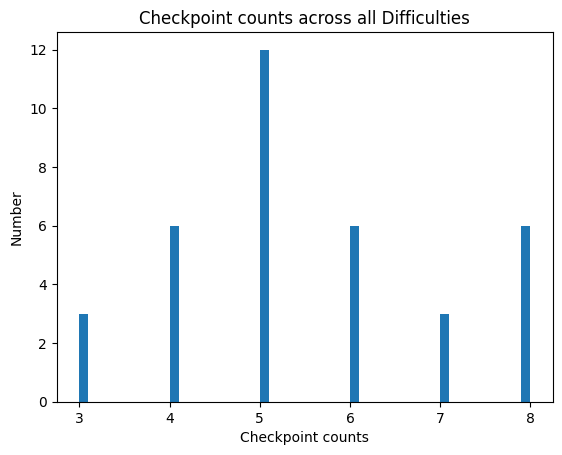

In [8]:
import matplotlib.pyplot as plt

data = df["checkpoint_counts"]

plt.figure()
plt.hist(data, bins=50)
plt.xlabel("Checkpoint counts")
plt.ylabel("Number")
plt.title("Checkpoint counts across all Difficulties")
plt.show()

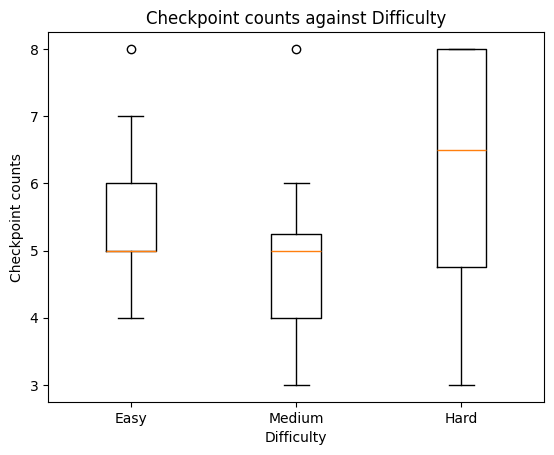

In [9]:
# Plot checkpoint counts against difficulty 
diff = ["Easy", "Medium", "Hard"]
data = [df.loc[df["difficulty"] == level, "checkpoint_counts"].values for level in diff]

plt.figure()
plt.boxplot(data, tick_labels=diff)
plt.xlabel("Difficulty")
plt.ylabel("Checkpoint counts")
plt.title("Checkpoint counts against Difficulty")
plt.show()

## Method to get problem instructions
Since the problem instruction is long, pass it as a separate file to the agent instead

In [10]:

# index refers to the problem number
def get_instruction_paths(scb_problems, index): 
    if index >= len(scb_problems):
        raise Exception("Index out of bounds")
    
    problem = Path(scb_problems[index]) 

    # filter .md files
    all_checkpoints = problem.glob("*.md")
    absolute_paths = sorted([path.resolve().as_posix() for path in all_checkpoints])
    
    # cut off the path before /datasets
    return list(map(lambda p: p[p.find("/datasets"):], absolute_paths))


In [11]:
i = 0
print(scb_problems[i].name)
get_instruction_paths(scb_problems, i)

cfgpipe


['/datasets/slopCodeBench/scb-problems/cfgpipe/checkpoint_1.md',
 '/datasets/slopCodeBench/scb-problems/cfgpipe/checkpoint_2.md',
 '/datasets/slopCodeBench/scb-problems/cfgpipe/checkpoint_3.md',
 '/datasets/slopCodeBench/scb-problems/cfgpipe/checkpoint_4.md',
 '/datasets/slopCodeBench/scb-problems/cfgpipe/checkpoint_5.md',
 '/datasets/slopCodeBench/scb-problems/cfgpipe/checkpoint_6.md']